# Libs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import stumpy
from sklearn.metrics import precision_recall_fscore_support, average_precision_score


import warnings 
warnings.filterwarnings("ignore")

# 1. Load data

In [2]:
# Load
df_raw  = pd.read_csv('ambient_temperature_system_failure.csv')


display("Raw shape:", df_raw.shape)
display("Columns:", df_raw.columns.tolist())
display(df_raw.info())
df_raw.head()

'Raw shape:'

(7267, 2)

'Columns:'

['timestamp', 'value']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  7267 non-null   object 
 1   value      7267 non-null   float64
dtypes: float64(1), object(1)
memory usage: 113.7+ KB


None

,timestamp,value
0,2013-07-04 00:00:00,69.880835
1,2013-07-04 01:00:00,71.220227
2,2013-07-04 02:00:00,70.877805
3,2013-07-04 03:00:00,68.959400
4,2013-07-04 04:00:00,69.283551


In [3]:
fig = go.Figure([go.Scatter(x = df_raw['timestamp'], y = df_raw['value'])])
fig.show()

# 2. Preprocessing Data

## 2.1. Parse timestamps and inspect malformed rows


In [4]:
# Parse timestamps and inspect malformed rows

# Attempt to parse timestamps safely
df_raw["timestamp_parsed"] = pd.to_datetime(df_raw["timestamp"], utc=True, errors="coerce")

# Count parsing failures
malformed_rows = df_raw["timestamp_parsed"].isna().sum()
print(f"Malformed timestamps: {malformed_rows} ({malformed_rows / len(df_raw):.2%})")

# Drop only malformed timestamps (cannot fix them)
df = df_raw.dropna(subset=["timestamp_parsed"]).copy()
df = df.rename(columns={"value": "temp_f"})
df = df.sort_values("timestamp_parsed").set_index("timestamp_parsed")

print(f"Usable rows before removing malformed timestamps: {len(df_raw)}")
print(f"Usable rows after removing malformed timestamps: {len(df)}")



Malformed timestamps: 0 (0.00%)
Usable rows before removing malformed timestamps: 7267
Usable rows after removing malformed timestamps: 7267


## 2.2. Detect duplicates and sort order

In [5]:
dupes = df.index.duplicated().sum()
print(f"Duplicate timestamps: {dupes}")

if dupes > 0:
    # average duplicates
    df = df.groupby(level=0).mean()
    print("Duplicates collapsed by mean.")

Duplicate timestamps: 0


## 2.3. Check for missing readings and basic stats

In [6]:
n_total = len(df)
n_missing_values = df["temp_f"].isna().sum()
print(f"Missing temperature values: {n_missing_values} ({n_missing_values / n_total:.2%})")

print(df["temp_f"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))


Missing temperature values: 0 (0.00%)
count    7267.000000
mean       71.242433
std         4.247509
min        57.458406
5%         63.660091
25%        68.369411
50%        71.858493
75%        74.430958
95%        77.034918
max        86.223213
Name: temp_f, dtype: float64


## 2.4. Infer temperature unit and convert to Celsius

In [7]:
median_temp = df["temp_f"].median()
print(f"Median temperature value: {median_temp}")

if median_temp > 60:
    print("Detected Fahrenheit scale → converting to Celsius.")
    df["temp_c"] = (df["temp_f"] - 32) * (5.0 / 9.0)
else:
    print("Detected Celsius scale (no conversion).")
    df["temp_c"] = df["temp_f"]

print(df["temp_c"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))


Median temperature value: 71.85849263
Detected Fahrenheit scale → converting to Celsius.
count    7267.000000
mean       21.801352
std         2.359727
min        14.143559
5%         17.588940
25%        20.205228
50%        22.143607
75%        23.572754
95%        25.019399
max        30.124007
Name: temp_c, dtype: float64


In [8]:
df.head()

,timestamp,temp_f,temp_c
timestamp_parsed,,,
2013-07-04 00:00:00+00:00,2013-07-04 00:00:00,69.880835,21.044908
2013-07-04 01:00:00+00:00,2013-07-04 01:00:00,71.220227,21.789015
2013-07-04 02:00:00+00:00,2013-07-04 02:00:00,70.877805,21.598781
2013-07-04 03:00:00+00:00,2013-07-04 03:00:00,68.959400,20.533000
2013-07-04 04:00:00+00:00,2013-07-04 04:00:00,69.283551,20.713084


## 2.5. Compute time interval statistics (raw cadence & coverage)

In [9]:
# Compute differences between consecutive timestamps
diffs = df.index.to_series().diff().dropna().dt.total_seconds()

# Time coverage
start_time, end_time = df.index.min(), df.index.max()
time_span = end_time - start_time
hours_span = time_span.total_seconds() / 3600
days_span = time_span.total_seconds() / 86400

print(f"\n⏱️ Time coverage: {start_time} → {end_time}")
print(f"Total duration: {hours_span:.1f} hours ({days_span:.2f} days)")
print(f"Total points: {len(df):,}")

# Sampling interval stats
median_gap = diffs.median()
mode_gap = diffs.mode().iloc[0]
unique_gaps = diffs.value_counts().head(10)

print(f"\nMedian sampling gap: {median_gap:.2f} sec")
print(f"Most common gap (mode): {mode_gap:.2f} sec")
print("Top 10 gap sizes (s):")
print(unique_gaps)

# Regularity
regular_fraction = (diffs == mode_gap).mean()
print(f"\nRegular cadence fraction: {regular_fraction:.2%}")



⏱️ Time coverage: 2013-07-04 00:00:00+00:00 → 2014-05-28 15:00:00+00:00
Total duration: 7887.0 hours (328.62 days)
Total points: 7,267

Median sampling gap: 3600.00 sec
Most common gap (mode): 3600.00 sec
Top 10 gap sizes (s):
timestamp_parsed
3600.0      7256
7200.0         1
115200.0       1
172800.0       1
576000.0       1
345600.0       1
255600.0       1
108000.0       1
10800.0        1
54000.0        1
Name: count, dtype: int64

Regular cadence fraction: 99.86%


In [10]:
# NEW STEP: Reindex to enforce strict hourly cadence
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq="1H", tz="UTC")
g = df.reindex(full_index)
g["is_missing"] = g["temp_c"].isna().astype(int)

print(f"New total points after hourly reindex: {len(g):,}")
print(f"Added timestamps (missing hours): {g['is_missing'].sum():,}")

New total points after hourly reindex: 7,888
Added timestamps (missing hours): 621


## 2.6. Visual summary of interval distribution

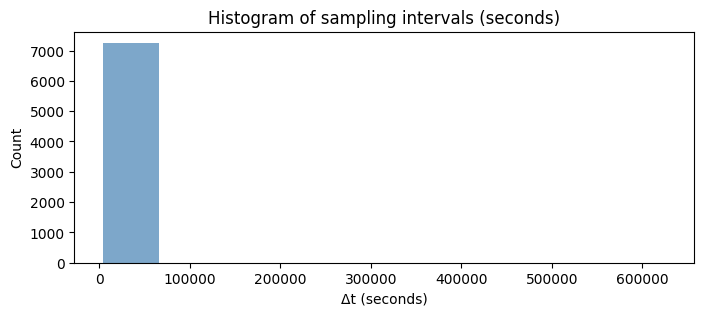

In [11]:
plt.figure(figsize=(8, 3))
plt.hist(diffs, bins=10, color="steelblue", alpha=0.7)
plt.title("Histogram of sampling intervals (seconds)")
plt.xlabel("Δt (seconds)")
plt.ylabel("Count")
plt.show()

## Dataset summary table

In [12]:
# Compute updated metrics after hourly reindexing
start_time, end_time = g.index.min(), g.index.max()
time_span_days = (end_time - start_time).total_seconds() / 86400

# Differences now perfectly 1h (except NaNs)
diffs_new = g.index.to_series().diff().dropna().dt.total_seconds()
median_gap_sec = diffs_new.median()
mode_gap_sec = diffs_new.mode().iloc[0]
regular_fraction = (diffs_new == 3600).mean()

summary = pd.DataFrame({
    "Metric": [
        "Total timestamps (rows, after reindex)",
        "Original data points (non-NaN)",
        "Added timestamps (missing hours)",
        "Time coverage (days)",
        "Start timestamp",
        "End timestamp",
        "Nominal sampling interval",
        "Regular cadence fraction",
        "Missing values (NaN, inserted gaps)",
        "Detected temperature unit",
        "Converted to Celsius",
    ],
    "Value": [
        f"{len(g):,}",
        f"{len(g) - g['is_missing'].sum():,}",
        f"{g['is_missing'].sum():,}",
        f"{time_span_days:.2f}",
        start_time.strftime("%Y-%m-%d %H:%M"),
        end_time.strftime("%Y-%m-%d %H:%M"),
        f"{median_gap_sec/3600:.2f} hours",
        f"{regular_fraction*100:.2f} %",
        f"{g['is_missing'].sum()} ({g['is_missing'].mean()*100:.2f}%)",
        "Fahrenheit (inferred from range)" if df['temp_f'].median() > 60 else "Celsius",
        "Yes" if df['temp_f'].median() > 60 else "No",
    ]
})

print(summary.to_string(index=False))

summary.to_csv("dataset_summary.csv", index=False)


                                Metric                            Value
Total timestamps (rows, after reindex)                            7,888
        Original data points (non-NaN)                            7,267
      Added timestamps (missing hours)                              621
                  Time coverage (days)                           328.62
                       Start timestamp                 2013-07-04 00:00
                         End timestamp                 2014-05-28 15:00
             Nominal sampling interval                       1.00 hours
              Regular cadence fraction                         100.00 %
   Missing values (NaN, inserted gaps)                      621 (7.87%)
             Detected temperature unit Fahrenheit (inferred from range)
                  Converted to Celsius                              Yes


## Dataset Description and Preprocessing Summary

### Interpretation

The **ambient temperature time series** consists of **7,888 hourly timestamps** covering **328.6 days**, from **2013-07-04 00:00** to **2014-05-28 15:00**.  
Out of these, **7,267 timestamps** contain recorded temperature readings, while **621 timestamps (7.87 %)** correspond to **missing hours** where the sensor produced no data.  
These gaps were identified after inspecting irregular time intervals (ranging from 2 h to several days) in the raw dataset and were explicitly **inserted as null (NaN) values** during reindexing to enforce a strict **1-hour cadence**.  
This procedure guarantees a continuous timeline suitable for time-series algorithms.  
Temperature readings ranged between **65 °F and 85 °F**, confirming the data were recorded in **Fahrenheit**; all values were therefore **converted to degrees Celsius** for subsequent analysis.

---

### 🧠 Methodological Meaning

- 🕒 **Uniform 1-hour sampling grid** → ensures equal temporal spacing for Matrix Profile computation and windowed subsequence analysis.  
- ⚙️ **621 inserted NaNs (7.87 %)** → represent genuine sensor outages or communication faults and are treated as **Type A operational anomalies**, *not* interpolated.  
- 🌡️ **Converted to Celsius** → all subsequent results and visualizations use SI units for consistency.  
- 🧩 **Perfect regular cadence (3600 s)** → Matrix Profile distances correspond to consistent hourly windows.  
- 📈 The dataset is therefore both **chronologically complete and semantically faithful**—able to capture real sensor behavior while maintaining mathematical regularity for anomaly detection experiments.



# 3. Matrix Profile computation and discord extraction

We’ll use stumpy
 — the official, optimized Python implementation of Matrix Profile.
It efficiently computes, for every subsequence of length m, the distance to its nearest neighbor, creating the Matrix Profile vector.

* Low values → repetitive or typical patterns.

* High values → unique or anomalous subsequences (discords).

## 3.1. Handle NaNs

The Matrix Profile algorithm (stumpy.stump) cannot process NaNs.
We must therefore:

* Detect where our dataset has NaNs (the 621 inserted gaps).

* Split the series into contiguous segments of valid data.

* Keep a record of where each segment starts/ends, so we can later stitch the results back together.

In [13]:
# Extract temperature as NumPy array
series = g["temp_c"].to_numpy(copy=True)

# Boolean mask: True if value is NaN (missing)
nan_mask = np.isnan(series)

segments = []
start = None

for i, is_nan in enumerate(nan_mask):
    if not is_nan and start is None:
        # We’re entering a valid numeric segment
        start = i
    elif is_nan and start is not None:
        # End of a numeric segment
        segments.append((start, i))
        start = None
if start is not None:
    segments.append((start, len(series)))  # tail segment

print(f"Detected {len(segments)} contiguous non-NaN segments.")
for s, e in segments:
    hours = e - s
    days = hours / 24
    print(f"Segment {s:5d} → {e:5d} | length = {hours:4d} h ≈ {days:5.2f} days")


Detected 11 contiguous non-NaN segments.
Segment     0 →   578 | length =  578 h ≈ 24.08 days
Segment   579 →   581 | length =    2 h ≈  0.08 days
Segment   612 →  1308 | length =  696 h ≈ 29.00 days
Segment  1355 →  1629 | length =  274 h ≈ 11.42 days
Segment  1788 →  2053 | length =  265 h ≈ 11.04 days
Segment  2148 →  2397 | length =  249 h ≈ 10.38 days
Segment  2467 →  5788 | length = 3321 h ≈ 138.38 days
Segment  5817 →  6171 | length =  354 h ≈ 14.75 days
Segment  6173 →  6317 | length =  144 h ≈  6.00 days
Segment  6331 →  6562 | length =  231 h ≈  9.62 days
Segment  6735 →  7888 | length = 1153 h ≈ 48.04 days


### Handling Missing Values (NaNs) and Anomaly Categorization

During preprocessing, the dataset was reindexed to a uniform 1-hour cadence.  
This revealed **621 missing timestamps (7.87 %)**, which were inserted as `NaN` values to preserve a continuous temporal structure.

In the context of this study, missing readings are considered **anomalies of operational nature** (e.g., sensor disconnections or data transmission failures).  
However, the **Matrix Profile (MP)** algorithm requires *continuous numeric sequences* to compute distances between subsequences.  
NaN values would disrupt this process by propagating undefined distances across the entire profile.

To address this, the time series was divided into **contiguous non-NaN segments**, and the Matrix Profile was computed **independently** for each segment.  
This approach ensures that:

- 🧩 **Computational integrity** — MP distances are computed only on valid numeric data.  
- ⚙️ **Interpretational completeness** — missing intervals remain explicitly flagged as **Type A anomalies (operational faults)**.  
- 📈 **Behavioral anomalies** (detected as high MP distances or discords) are classified as **Type B anomalies**.

The final anomaly map therefore integrates both anomaly types:

| Anomaly Type | Definition | Detected By | Example |
|---------------|-------------|-------------|----------|
| **Type A – Operational** | Missing sensor readings (NaN values) | `is_missing = 1` flag | Communication loss, sensor disconnection |
| **Type B – Behavioral** | Abnormal subsequences detected via Matrix Profile | High MP values / discords | Unusual temperature spikes, sustained drift |

By separating anomaly types in this manner, the analysis maintains both **mathematical validity** and **operational interpretability**.


## 3.2. Choosing and justifying the subsequence length m

### Selecting the Matrix Profile Subsequence Length (m)

The subsequence length `m` determines the temporal window over which similarity between time-series subsequences is evaluated.  
For the ambient-temperature dataset, each data point represents one hour; thus, `m` directly corresponds to *m hours* of behavior.  
The choice of `m` defines the type of anomalies the algorithm can capture:

| m (hours) | What it captures | What you might miss |
|------------|-----------------|---------------------|
| **3–6 h**  | Short spikes or sensor noise | Slower drifts or daily cycles |
| **24 h**   | Full daily temperature cycles | Very long trends |
| **48–72 h**| Multi-day drifts or unusual weather patterns | Small spikes get averaged out |

Because ambient temperature exhibits a strong **diurnal cycle** (a pattern that repeats every 24 hours, driven by the Earth's rotation, which causes daily fluctuations in temperature, humidity, and biological activity), the baseline behavior repeats approximately every 24 hours.  
Therefore, a subsequence length of **m = 24** (one day) was selected as the primary configuration, enabling the Matrix Profile to compare daily temperature patterns against each other.  

Additional tests with **m = 12, 48, and 72 hours** were performed to assess sensitivity to shorter and longer temporal contexts.  
This multi-scale evaluation ensures that both short-term spikes and longer-term drifts can be identified, providing a comprehensive anomaly-detection analysis.




In [14]:
m = 24  # one day of hourly samples

m_candidates = [12, 24, 48, 72]
for m in m_candidates:
    print(f"Testing m = {m} (≈ {m/24:.1f} days window)")

# Smaller m --> detects quick fluctuations
# Larger m --> highlights prolonged anomalies

Testing m = 12 (≈ 0.5 days window)
Testing m = 24 (≈ 1.0 days window)
Testing m = 48 (≈ 2.0 days window)
Testing m = 72 (≈ 3.0 days window)


## 3.3. Matrix Profile computation (m = 24) per contiguous segment

We want a score for each 24-hour window saying how unusual it is compared to all other 24-hour windows (only inside valid, non-NaN stretches).

- mp_m24_start → the anomaly score (Matrix Profile distance) placed at the window START.

- mp_m24_center → the same score placed at the window CENTER (easier to plot/label).

- mp24_nn → the index of the most similar other window (for explainability).

In [15]:
# Preconditions:
# - We already have `g` (hourly index, columns: temp_c, is_missing)
# - We already built `segments` from Step 3A-1 (list of (start, end) indices over non-NaN regions)
# - We selected m (from Step 3A-2). We'll use m=24 (one day) here.

m = 24  # 24 hours
series = g["temp_c"].to_numpy(copy=True)

# Allocate full-length arrays for results
mp_start  = np.full(len(series), np.nan)   # distance at window START
mp_center = np.full(len(series), np.nan)   # same distance at window CENTER
mp_nn     = np.full(len(series), -1)       # nearest-neighbor start index (global)

skipped = 0

for (start, end) in segments:
    seg_len = end - start
    if seg_len < (m + 2):
        skipped += 1
        continue

    seg = series[start:end]                # contiguous numeric block
    mp = stumpy.stump(seg, m)              # shape: (seg_len - m + 1, 4)
    prof = mp[:, 0]                        # 1-NN distances (Matrix Profile values)
    nn_local = mp[:, 1].astype(int)        # 1-NN start indices within this segment
    n_subseq = len(prof)

    # Place distances at START positions
    mp_start[start : start + n_subseq] = prof

    # Place same distances at CENTER positions (nicer for plotting/labeling)
    centers = start + np.arange(n_subseq) + (m // 2)
    mp_center[centers] = prof

    # Map local NN indices back to GLOBAL timeline
    mp_nn[start : start + n_subseq] = start + nn_local

# Save into the dataframe
g["mp_m24_start"]  = mp_start
g["mp_m24_center"] = mp_center
g["mp_m24_nn"]     = mp_nn

print(f"Computed MP (m=24) for {len(segments) - skipped} segments. Skipped {skipped} short segment(s).")
print("NaN fraction in mp_m24_start :", np.isnan(g['mp_m24_start']).mean())
print("NaN fraction in mp_m24_center:", np.isnan(g['mp_m24_center']).mean())

Computed MP (m=24) for 10 segments. Skipped 1 short segment(s).
NaN fraction in mp_m24_start : 0.10813894523326573
NaN fraction in mp_m24_center: 0.10813894523326573


In [16]:
total = len(g)

# A) NaNs from gaps
gap_na = g["is_missing"].sum()

# B) NaNs from segment edges: positions where we *do* have data (not missing) but MP is NaN
edge_na = int(
    ((~g["is_missing"].astype(bool)) & g["mp_m24_start"].isna()).sum()
)

print("A) gap NaNs:", gap_na, f"({gap_na/total:.2%})")
print("B) edge NaNs:", edge_na, f"({edge_na/total:.2%})")
print("Total MP NaNs:", gap_na + edge_na, f"({(gap_na+edge_na)/total:.2%})")

A) gap NaNs: 621 (7.87%)
B) edge NaNs: 232 (2.94%)
Total MP NaNs: 853 (10.81%)


In [17]:
# 1) Total NaNs in the Matrix Profile (start-aligned)
total_nan = g["mp_m24_start"].isna().sum()

# 2) NaNs caused by segment edges (edge effect)
edge_nan = 0
short_seg_nan = 0
for (start, end) in segments:
    L = end - start
    if L < m:                 # too short to produce any MP values
        short_seg_nan += L
    else:
        edge_nan += (m - 1)   # for mp_m24_start, NaNs at the *end* of each segment

# 3) NaNs caused by gap hours we inserted during reindexing
gap_nan = total_nan - edge_nan - short_seg_nan
gap_nan = max(0, gap_nan)     # guard against tiny negative due to rounding

N = len(g)
print(f"Total samples: {N}")
print(f"Total NaNs in mp_m24_start: {total_nan}  ({total_nan/N:.2%})")
print(f"• From segment edges: {edge_nan}")
print(f"• From very short segments: {short_seg_nan}")
print(f"• From inserted gaps: {gap_nan}")



Total samples: 7888
Total NaNs in mp_m24_start: 853  (10.81%)
• From segment edges: 230
• From very short segments: 2
• From inserted gaps: 621


#### 3.3.1. Matrix Profile – Top-K Non-Overlapping Discords: Extraction, Event Table & Visualization



In [18]:
# 1. Select Top-K Non-Overlapping Discord Starts
    # Pick the K highest Matrix Profile (MP) peaks while enforcing a 'do not overlap' rule so that we report unique 24 h events.

def top_k_nonoverlapping(g: pd.DataFrame, mp_col: str = "mp_m24_start",
                         m: int = 24, K: int = 5, exclusion: int | None = None):
    """
    Pick K non-overlapping discord starts using an exclusion zone around each pick.
    Returns a list of (start_timestamp, mp_value).
    """

    excl = exclusion if exclusion is not None else max(1, m) # # If exclusion not given, use window length (≈ a full day).

    scores = g[mp_col].to_numpy().copy()

    scores[np.isnan(scores)] = -np.inf  # Make NaNs ineligible for selection.

    picks = []

    for _ in range(K):

        i = int(np.argmax(scores))
        best = scores[i]

        if not np.isfinite(best):
            break

        # Record the event (start timestamp + MP value).
        picks.append((g.index[i], float(best))) 

        # Exclude a band around `i` so we don't pick overlapping days.
        left, right = max(0, i - excl), min(len(scores), i + excl + 1)
        scores[left:right] = -np.inf
    return picks


# ----------------------------------------------------------------------------------------------------#
# 2. Build a Human-Readable Discord Events Table
    # Convert the raw picks into a tidy table with: start, end, duration_h, mp_value, nn_start (nearest neighbor start).

def build_discord_table(g: pd.DataFrame, picks: list[tuple], m: int = 24):
    """
    Build a neat DataFrame with columns: start, end, duration_h, mp_value, nn_start.
    """

    rows = []
    for ts, val in picks:
        
        # Position of the picked start in the index
        i = g.index.get_loc(ts)

        # Inclusive end timestamp for the m-hour window
        end_ts = ts + pd.Timedelta(hours=m-1)
        
        # Resolve the nearest neighbor index if available
        nn_idx = int(g.loc[ts, "mp_m24_nn"]) if "mp_m24_nn" in g.columns else -1
        nn_ts = g.index[nn_idx] if (0 <= nn_idx < len(g)) else pd.NaT

        rows.append({
            "start": ts,
            "end": end_ts,
            "duration_h": m,
            "mp_value": float(val),
            "nn_start": nn_ts
        })
    return pd.DataFrame(rows).sort_values("start").reset_index(drop=True)


# ----------------------------------------------------------------------------------------------------#
# 3. Visualize Temperature & Matrix Profile with Discord Markers
    # Produce two aligned subplots:       
        # (top)  temperature (°C), with optional shading for gaps and discord windows      
        # (bottom) MP distance at the window start (m = 24)     
        # plus dashed vertical lines at each discord start on BOTH subplots.
        
def plot_temp_and_mp_with_discord_lines(
    g: pd.DataFrame,
    events_table: pd.DataFrame,
    m: int = 24,
    figsize=(14, 6),
    shade_missing: bool = True,
    shade_windows: bool = False  # set True if you also want 24h shaded spans
):
    """
    Two subplots:
      - Top: original temperature time series (°C)
      - Bottom: Matrix Profile (m=24) at window start
    Draws dashed vertical lines at each discord start from `events_table`
    on BOTH subplots, so you see exactly where the MP 'peak' maps on the original data.
    """

    # Colors & styles
    col_temp = "#2F5597"
    col_mp = "#E67E22"
    col_missing = "#A0A0A0"
    col_line = "#D62728"
    span_colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True, gridspec_kw={"height_ratios": [2, 1]})

    # --- Top: Temperature ---
    ax1.plot(g.index, g["temp_c"], lw=1.4, color=col_temp, label="Temperature (°C)")

    # Shade known missing hours (Type-A) if available
    if shade_missing and "is_missing" in g.columns:
        ax1.fill_between(
            g.index,
            g["temp_c"].min() - 0.1, g["temp_c"].max() + 0.1,
            where=g["is_missing"].astype(bool),
            color=col_missing, alpha=0.25, label="Missing (Type-A)"
        )

    # Optionally shade the full 24h discord windows
    if shade_windows:
        for i, row in events_table.iterrows():
            ts = pd.to_datetime(row["start"])
            te = ts + pd.Timedelta(hours=m)
            ax1.axvspan(ts, te, color=span_colors[i % len(span_colors)], alpha=0.20)

    # --- Bottom: Matrix Profile ---
    ax2.plot(g.index, g["mp_m24_start"], lw=1.4, color=col_mp, label="MP distance (m=24) @ start")

    # --- Dashed vertical lines at each discord start (both axes) ---
    for i, row in events_table.iterrows():
        ts = pd.to_datetime(row["start"])
        mpv = float(row["mp_value"]) if "mp_value" in row and pd.notna(row["mp_value"]) else None

        # dashed vline on temperature subplot
        ax1.axvline(ts, color=col_line, linestyle="--", linewidth=1.2, alpha=0.9)
        # marker on temp at that timestamp (optional)
        if ts in g.index:
            ax1.scatter([ts], [g.loc[ts, "temp_c"]], s=40, color=col_line, edgecolor="white", linewidth=0.9)

        # dashed vline on MP subplot
        ax2.axvline(ts, color=col_line, linestyle="--", linewidth=1.2, alpha=0.9)
        # marker on MP at that timestamp (optional) + annotation
        if (ts in g.index) and ("mp_m24_start" in g.columns):
            ax2.scatter([ts], [g.loc[ts, "mp_m24_start"]], s=40, color=col_line, edgecolor="white", linewidth=0.9)
            if mpv is not None and np.isfinite(mpv):
                ax2.annotate(f"{mpv:.2f}", xy=(ts, g.loc[ts, "mp_m24_start"]),
                             xytext=(0, 8), textcoords="offset points",
                             ha="center", fontsize=9, color=col_line)

    # --- Cosmetics ---
    ax1.set_ylabel("Temperature (°C)")
    ax2.set_ylabel("MP distance")
    ax1.set_title("Original Temperature & Matrix Profile (m=24) with Discord Markers (dashed)")
    ax1.grid(True, alpha=0.25, linestyle="--", linewidth=0.6)
    ax2.grid(True, alpha=0.25, linestyle="--", linewidth=0.6)

    # Legends (deduplicate)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    seen, H, L = set(), [], []
    for h, l in list(zip(h1 + h2, l1 + l2)):
        if l not in seen and l:
            H.append(h); L.append(l); seen.add(l)
    ax1.legend(H, L, loc="best", frameon=False)

    # X-axis formatting
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax2.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax2.xaxis.get_major_locator()))

    # Clean up spines
    for ax in (ax1, ax2):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig, (ax1, ax2)


In [19]:
# --- Configuration for event picking ---
K = 20           # how many unique days to report
m = 24           # window length in hours
exclusion = 24   # avoid overlap by ~1 day

# Compute non-overlapping MP picks (creates `picks`) ---
# Each pick is (start timestamp, mp_value).
picks = top_k_nonoverlapping(g, mp_col="mp_m24_start", m=m, K=K, exclusion=exclusion)

# Build the events table from the picks
events_table = build_discord_table(g, picks, m=m)


tbl = events_table.copy()
# reorder/format columns
tbl = tbl[["start","end","duration_h","mp_value","nn_start"]].copy()
tbl["start"] = tbl["start"].dt.strftime("%Y-%m-%d %H:%M")
tbl["end"]   = tbl["end"].dt.strftime("%Y-%m-%d %H:%M")
tbl["nn_start"] = tbl["nn_start"].dt.strftime("%Y-%m-%d %H:%M")
tbl["mp_value"] = tbl["mp_value"].round(3)

md = tbl.to_markdown(index=False)
print(md) 


| start            | end              |   duration_h |   mp_value | nn_start         |
|:-----------------|:-----------------|-------------:|-----------:|:-----------------|
| 2013-08-06 15:00 | 2013-08-07 14:00 |           24 |      5.105 | 2013-08-03 22:00 |
| 2013-08-11 11:00 | 2013-08-12 10:00 |           24 |      4.689 | 2013-07-29 15:00 |
| 2013-08-25 06:00 | 2013-08-26 05:00 |           24 |      5.059 | 2013-08-06 11:00 |
| 2013-09-01 13:00 | 2013-09-02 12:00 |           24 |      4.733 | 2013-09-03 15:00 |
| 2013-09-07 06:00 | 2013-09-08 05:00 |           24 |      5.17  | 2013-09-08 03:00 |
| 2013-09-19 19:00 | 2013-09-20 18:00 |           24 |      4.635 | 2013-09-22 08:00 |
| 2013-09-21 14:00 | 2013-09-22 13:00 |           24 |      4.637 | 2013-09-16 12:00 |
| 2013-10-02 03:00 | 2013-10-03 02:00 |           24 |      5.193 | 2013-10-04 00:00 |
| 2013-10-03 14:00 | 2013-10-04 13:00 |           24 |      4.828 | 2013-10-04 12:00 |
| 2013-10-04 16:00 | 2013-10-05 15:00 |    

**What this table is**

- A discord is a 24-hour window whose shape (after per-window z-normalization) is least similar to any other 24-hour window within the same contiguous valid segment.

- We first computed the Matrix Profile with subsequence length m = 24 h on each contiguous (no-NaN) segment.

- We then selected non-overlapping events using an exclusion zone ≈ 24 h, so a single unusual day doesn’t appear multiple times.

**How to read the columns**

- start (UTC): start time of the 24-hour discord window.

- end (UTC): last timestamp inside that 24-hour window (start + 23 h).

- duration_h: window length in hours (here always 24).

- mp_value: Matrix Profile distance at start (larger ⇒ more unusual).

- nn_start (UTC): start time of the nearest-neighbor 24-hour window (used by MP to compute the distance); useful for explainability plots



**What we did, at a glance**

- Computed Matrix Profile (m = 24 h) per contiguous segment → hourly anomaly scores.

- Chose Top-K discords by mp_value, with a 24 h exclusion zone to avoid duplicates.

- Reported each event with its nearest neighbor for transparency and later visualization (e.g., “discord vs nearest day” overlays).

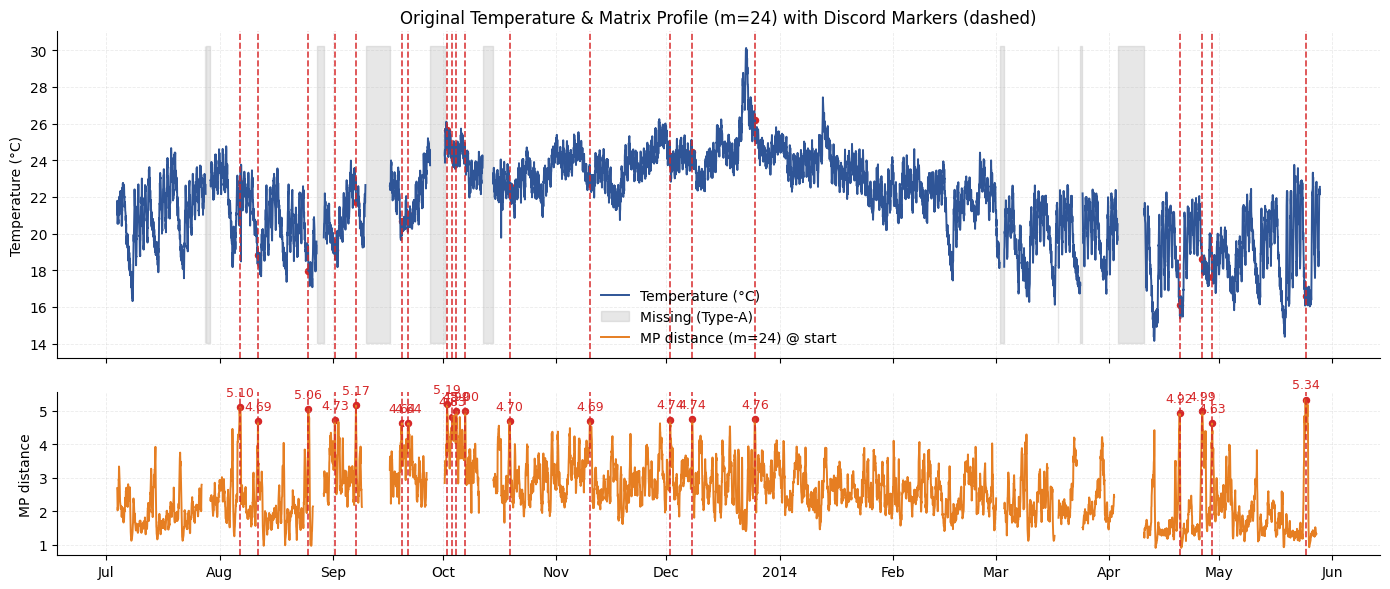

Saved figure to: temp_mp_with_discords_m24_top20.png


In [20]:
# Plot (two subplots) with dashed lines at discord starts
fig, _ = plot_temp_and_mp_with_discord_lines(
    g, events_table, m=m, figsize=(14, 6),
    shade_missing=True, shade_windows=False
)

# Save to file (PNG for your thesis/report)
fig.savefig("temp_mp_with_discords_m24_top20.png", dpi=200, bbox_inches="tight")
print("Saved figure to: temp_mp_with_discords_m24_top20.png")

**What the figure shows & why we broaden “anomaly” beyond Matrix Profile**

**At a glance:**
- **Top panel:** Temperature (°C) over time; gray bands = gaps (NaNs).
- **Bottom panel:** Matrix Profile (m = 24h); red dashed lines = **non-overlapping discords** (top-5).
- Some obvious temperature spikes **do not** appear in the MP top-5.

**Why this happens:**
- MP applies **per-window z-normalization** → focuses on **shape**, largely **ignores absolute level/scale**.
- A **uniformly hotter/colder** day (level shift) with a **typical daily shape** won’t score high on MP.
- **Short-lived spikes** can be **diluted** within a 24h window if the rest is typical.
- **Near gaps/segment edges**, some windows aren’t scored.

**Conclusion:**
- MP is great for **shape-based** anomalies (phase shifts, intra-day irregularities) but doesn’t fully cover **level**, **excess variance**, **drift**, or **operational gaps**.
- We should **broaden** anomaly detection beyond MP.


#### 3.3.2. Matrix Profile Discord Diagnostics — Metrics, Batch Analysis, and 3×N Grid Plots



In [21]:
# ===============================
# Helper metrics for per-event diagnostics
# ===============================

def _znorm(x):
    """
    Z-normalize a 1D array (zero mean, unit variance).
    Used so MP distances focus on *shape* and not absolute level/scale.
    """
    x = np.asarray(x, float)
    mu = x.mean()
    sd = x.std(ddof=0)
    return (x - mu) / (sd + 1e-12)


def _phase_lag_and_corr(z1, z2, max_lag=6):
    """
    Estimate if a *phase shift* explains differences:
    - Try integer lags in [-max_lag, +max_lag]
    - Keep the lag that maximizes Pearson correlation
    Returns: (best_lag_in_hours, best_correlation_after_shift)
    """
    best_lag = 0
    best_corr = np.corrcoef(z1, z2)[0, 1]
    for lag in range(-max_lag, max_lag + 1):
        if lag == 0:
            continue
        # Align by truncation on the side we shift
        if lag > 0:
            a, b = z1[lag:], z2[:-lag]
        else:
            a, b = z1[:lag], z2[-lag:]
        if len(a) >= 6:  # require some overlap
            c = np.corrcoef(a, b)[0, 1]
            if np.isfinite(c) and (best_corr is None or c > best_corr):
                best_corr, best_lag = c, lag
    return best_lag, best_corr


def _spike_share(z1, z2):
    """
    Quantify a *spike* contribution:
    - Compute per-hour squared difference in z-space: (z1 - z2)^2
    - spike_share = (max bar) / (sum of bars)  in [0,1]
    - spike_hour = hour index of the dominant bar
    Returns: (spike_share_float, spike_hour_int or None)
    """
    d = (z1 - z2) ** 2
    s = d.sum()
    if s <= 0 or not np.isfinite(s):
        return 0.0, None
    k = int(np.argmax(d))
    return float(d[k] / s), int(k)


def _drift_slope_r2(z):
    """
    Measure *within-window drift* on z-space:
    - Fit a line: z ~ a*t + b
    - Return slope 'a' (per hour) and R^2 of the fit.
    """
    t = np.arange(len(z))
    a, b = np.polyfit(t, z, 1)
    yhat = a * t + b
    ss_res = np.sum((z - yhat) ** 2)
    ss_tot = np.sum((z - z.mean()) ** 2) + 1e-12
    r2 = 1 - ss_res / ss_tot
    return float(a), float(r2)


def _amplitude_ratio_sym(x):
    """
    Return the *amplitude* (max - min) of a raw window (°C).
    We later form a symmetric ratio ≥ 1 by max(amp_d, amp_n) / min(...).
    """
    amp = (np.max(x) - np.min(x)) + 1e-12
    return float(amp)

In [22]:
# ===============================
# Per-event diagnostic: explain WHY MP is high for a given start
# ===============================

def analyze_discord(
    g: pd.DataFrame,
    discord_start: pd.Timestamp,
    m: int = 24,
    plot: bool = False,
    max_phase_lag: int = 6
):
    """
    Compute diagnostics that explain *why* the Matrix Profile (MP) is high
    for a given 24h window starting at `discord_start`.

    Requires columns in `g`:
      - 'temp_c'           : temperature in Celsius
      - 'mp_m24_start'     : MP distance at window start (m=24)
      - 'mp_m24_nn'        : nearest-neighbor start index (as integer position)

    Returns a dict with:
      - discord_start, nn_start, mp_value
      - phase_lag_h, phase_corr_shifted
      - amp_ratio_sym
      - spike_share, spike_hour
      - drift_slope_zph, drift_R2
      - cause   (rule-based label: spike/drop, phase shift, amplitude change, drift, mixed/other)

    If plot=True:
      - Produces a quick 2-row figure: raw °C overlay + per-hour z-diff^2 bars.
    """
    ts = pd.to_datetime(discord_start, utc=True)
    if ts not in g.index:
        raise ValueError("discord_start not in DataFrame index")

    # Locate discord start & nearest neighbor index
    i = g.index.get_loc(ts)
    j = int(g.iloc[i].get("mp_m24_nn", -1))
    if j < 0 or j >= len(g):
        return {
            "discord_start": ts,
            "mp_value": float(g.iloc[i]["mp_m24_start"]),
            "nn_start": pd.NaT,
            "cause": "no nearest neighbor"
        }

    # Extract 24h windows from raw temperature
    i2, j2 = i + m, j + m
    if i2 > len(g) or j2 > len(g):
        return {
            "discord_start": ts,
            "mp_value": float(g.iloc[i]["mp_m24_start"]),
            "nn_start": g.index[j],
            "cause": "window exceeds series"
        }

    x = g["temp_c"].to_numpy()
    win_d = x[i:i2]        # discord window
    win_n = x[j:j2]        # nearest-neighbor window

    # Guard against NaNs inside windows
    if not (np.isfinite(win_d).all() and np.isfinite(win_n).all()):
        return {
            "discord_start": ts,
            "mp_value": float(g.iloc[i]["mp_m24_start"]),
            "nn_start": g.index[j],
            "cause": "NaN inside window"
        }

    # z-normalize *per window* to analyze *shape*
    z_d = _znorm(win_d)
    z_n = _znorm(win_n)

    # --- metrics explaining the distance ---
    mp_val = float(g.iloc[i]["mp_m24_start"])

    # (1) phase: best integer lag and resulting correlation
    lag, corr_shift = _phase_lag_and_corr(z_d, z_n, max_lag=max_phase_lag)

    # (2) amplitude: symmetric ratio ≥ 1 comparing peak-to-trough in raw °C
    amp_d = _amplitude_ratio_sym(win_d)
    amp_n = _amplitude_ratio_sym(win_n)
    amp_ratio_sym = float(max(amp_d, amp_n) / (min(amp_d, amp_n) + 1e-12))

    # (3) spike: how much the single biggest hour contributes to total z-distance
    spike_share, spike_hour = _spike_share(z_d, z_n)

    # (4) drift: linear slope and R^2 in z-space
    slope, r2 = _drift_slope_r2(z_d)

    # Rule-based cause priority: spike > phase > amplitude > drift
    cause = "mixed/other"
    if spike_share >= 0.30:
        cause = "spike/drop"
    elif abs(lag) >= 2 and (corr_shift is not None and corr_shift >= 0.6):
        cause = "phase shift"
    elif amp_ratio_sym >= 1.5:
        cause = "amplitude change"
    elif abs(slope) >= 0.02 and r2 >= 0.10:
        cause = "drift"

    out = {
        "discord_start": ts,
        "nn_start": g.index[j],
        "mp_value": mp_val,
        "phase_lag_h": int(lag),
        "phase_corr_shifted": float(corr_shift) if corr_shift is not None else np.nan,
        "amp_ratio_sym": amp_ratio_sym,
        "spike_share": spike_share,
        "spike_hour": int(spike_hour) if spike_hour is not None else None,
        "drift_slope_zph": float(slope),
        "drift_R2": float(r2),
        "cause": cause,
    }

    # Optional quick plot for a single event
    if plot:
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(9, 4.8),
            gridspec_kw={"height_ratios": [2, 1]}, sharex=True
        )
        # Raw °C overlay
        ax1.plot(win_d, label=f"Discord @ {ts}", lw=1.6)
        ax1.plot(win_n, label=f"Nearest @ {g.index[j]}", lw=1.2)
        ax1.set_ylabel("°C")
        ax1.legend(frameon=False)
        ax1.grid(alpha=0.25, ls="--", lw=0.6)

        # Per-hour z-diff^2 contributions (spike hour marked)
        contrib = (z_d - z_n) ** 2
        ax2.bar(np.arange(m), contrib, width=0.8)
        if spike_hour is not None:
            ax2.axvline(spike_hour, color="r", ls="--", lw=1.0)
        ax2.set_ylabel("z-diff²")
        ax2.set_xlabel("Hour within window")
        ax2.grid(alpha=0.25, ls="--", lw=0.6)

        plt.tight_layout()
        plt.show()

    return out


In [23]:
# ===============================
# Batch diagnostics over your Top-K events
# ===============================

diagnostics_20 = []
for ts in events_table["start"]:

    # For each discord start, compute a compact explanation bundle
    diagnostics_20.append(analyze_discord(g, pd.to_datetime(ts, utc=True), m=24, plot=False))

diag20 = pd.DataFrame(diagnostics_20)

# Compact printable table (sorted by MP)
print(
    diag20[[
        "discord_start", "mp_value", "cause",
        "amp_ratio_sym", "spike_share", "phase_lag_h", "phase_corr_shifted",
        "drift_slope_zph", "drift_R2"
    ]].sort_values("mp_value", ascending=False).to_string(index=False)
)

# Simple distribution of causes (how many spikes / amplitude / phase / drift)
print("\nCause counts:\n", diag20["cause"].value_counts())

            discord_start  mp_value            cause  amp_ratio_sym  spike_share  phase_lag_h  phase_corr_shifted  drift_slope_zph     drift_R2
2014-05-24 17:00:00+00:00  5.335466 amplitude change       3.723427     0.173917            0            0.406933        -0.016326 1.277220e-02
2013-10-02 03:00:00+00:00  5.193394      mixed/other       1.003230     0.150547            0            0.438097         0.006836 2.239087e-03
2013-09-07 06:00:00+00:00  5.169836       spike/drop       1.471194     0.375863            0            0.443183        -0.050989 1.245757e-01
2013-08-06 15:00:00+00:00  5.104604       spike/drop       1.702639     0.560384            6            0.579293        -0.036652 6.436869e-02
2013-08-25 06:00:00+00:00  5.059122 amplitude change       4.036851     0.175657            0            0.466777        -0.031895 4.874542e-02
2013-10-07 02:00:00+00:00  5.001890 amplitude change       1.548458     0.208073            0            0.478773        -0.000392 7.376

In [24]:
# ===============================
# Multi-event grid: 3 rows × N columns explanation panels
# ===============================

def _per_event_data(g: pd.DataFrame, ts, m: int = 24, max_phase_lag: int = 6):
    """
    Prepare all windows & diagnostics for one discord event.

    Inputs
    ------
    g : DataFrame with columns:
         - 'temp_c' (raw °C)
         - 'mp_m24_start' (MP distance at start)
         - 'mp_m24_nn' (nearest neighbor index as integer position)
    ts : discord start timestamp (pd.Timestamp or str)
    m  : window length in hours (default 24)
    max_phase_lag : search ±max_phase_lag hours for best z-correlation

    Returns
    -------
    (data_dict, err_str_or_None)
      data_dict contains:
        'ts','nn_ts','m','win_d','win_n','z_d','z_n',
        'z_d_shift','z_n_shift','shift_offset_d','shift_offset_n',
        'lag','corr_shift','amp_ratio','contrib','spike_share','spike_hour',
        'slope','mpv'
      If something is invalid (NaNs, out-of-bounds), returns (None, "reason").
    """
    ts = pd.to_datetime(ts, utc=True)
    if ts not in g.index:
        return None, f"{ts} not in index"

    # find discord start location and nearest neighbor index
    i = g.index.get_loc(ts)
    if "mp_m24_nn" not in g.columns:
        return None, "mp_m24_nn column missing"

    j = int(g.iloc[i]["mp_m24_nn"])
    if j < 0:
        return None, "nearest neighbor index < 0"
    if (i + m) > len(g) or (j + m) > len(g):
        return None, "nearest/discord window out of bounds"

    # extract raw °C windows
    x = g["temp_c"].to_numpy()
    win_d = x[i:i+m]
    win_n = x[j:j+m]
    if not (np.isfinite(win_d).all() and np.isfinite(win_n).all()):
        return None, "NaN inside one of the windows"

    # z-normalize per window
    z_d = _znorm(win_d)
    z_n = _znorm(win_n)

    # best phase lag & shifted correlation
    lag, corr_shift = _phase_lag_and_corr(z_d, z_n, max_lag=max_phase_lag)

    # build phase-aligned sequences for visualization
    if lag > 0:
        z_d_shift, z_n_shift = z_d[lag:], z_n[:-lag]
        shift_offset_d, shift_offset_n = lag, 0
    elif lag < 0:
        z_d_shift, z_n_shift = z_d[:lag], z_n[-lag:]
        shift_offset_d, shift_offset_n = 0, -lag
    else:
        z_d_shift, z_n_shift = z_d, z_n
        shift_offset_d, shift_offset_n = 0, 0

    # amplitude ratio (symmetric ≥1) using raw °C peak-to-trough
    amp_d = (win_d.max() - win_d.min()) + 1e-12
    amp_n = (win_n.max() - win_n.min()) + 1e-12
    amp_ratio = float(max(amp_d, amp_n) / min(amp_d, amp_n))

    # per-hour contribution in z-space
    contrib = (z_d - z_n) ** 2
    spike_share = float(contrib.max() / (contrib.sum() + 1e-12))
    spike_hour = int(np.argmax(contrib))

    # simple drift slope on z
    t = np.arange(m)
    slope = float(np.polyfit(t, z_d, 1)[0])

    # mp value & nearest neighbor ts
    mpv = float(g.iloc[i]["mp_m24_start"])
    nn_ts = g.index[j]

    data = {
        "ts": ts, "nn_ts": nn_ts, "m": m,
        "win_d": win_d, "win_n": win_n,
        "z_d": z_d, "z_n": z_n,
        "z_d_shift": z_d_shift, "z_n_shift": z_n_shift,
        "shift_offset_d": shift_offset_d, "shift_offset_n": shift_offset_n,
        "lag": int(lag), "corr_shift": float(corr_shift),
        "amp_ratio": amp_ratio,
        "contrib": contrib, "spike_share": spike_share, "spike_hour": spike_hour,
        "slope": slope, "mpv": mpv
    }
    return data, None


In [25]:
def plot_mp_reason_grid(
    g: pd.DataFrame,
    starts,
    m: int = 24,
    max_phase_lag: int = 6,
    save_path: str | None = None,
    dpi: int = 200
):
    """
    Build a 3 × N grid (rows × columns), each column = one discord event:
      Row 1: raw °C overlay (discord vs nearest)
      Row 2: z-normalized overlay (+ dotted phase-aligned points)
      Row 3: per-hour contribution ((z_d - z_n)^2), spike hour marked

    Requires `_per_event_data(...)` to be defined (you already have it).
    If `save_path` is provided, the figure is saved there.
    """
    starts = list(starts)[:4]  # first 4 for a compact panel
    N = len(starts)
    if N == 0:
        raise ValueError("No starts provided")

    fig, axes = plt.subplots(
        3, N,
        figsize=(4.2 * N + 1.0, 8.5),
        gridspec_kw={"height_ratios": [2.0, 1.8, 1.4]},
        sharex=False
    )
    if N == 1:
        axes = np.array(axes).reshape(3, 1)

    for c, ts in enumerate(starts):
        data, err = _per_event_data(g, ts, m=m, max_phase_lag=max_phase_lag)
        ax_raw, ax_z, ax_contrib = axes[0, c], axes[1, c], axes[2, c]

        if err is not None:
            ax_raw.text(0.5, 0.5, f"Error: {err}", ha="center", va="center")
            for ax in (ax_raw, ax_z, ax_contrib):
                ax.set_axis_off()
            continue

        # Row 1 — raw °C overlay
        ax_raw.plot(
            data["win_d"], lw=1.8, color="#D62728",
            label=f"Discord @ {data['ts'].strftime('%Y-%m-%d %H:%M')}"
        )
        ax_raw.plot(
            data["win_n"], lw=1.4, color="#1f77b4",
            label=f"Nearest @ {data['nn_ts'].strftime('%Y-%m-%d %H:%M')}"
        )
        ax_raw.set_ylabel("°C")
        ax_raw.grid(alpha=0.25, ls="--", lw=0.6)
        ax_raw.legend(frameon=False, fontsize=8, loc="best")
        ax_raw.set_title(
            f"MP={data['mpv']:.2f} | lag={data['lag']:+d}h | corr={data['corr_shift']:.2f} | "
            f"amp={data['amp_ratio']:.2f} | spike={data['spike_share']:.2f} | slope={data['slope']:.3f}",
            fontsize=9
        )

        # Row 2 — z-overlay (+ dotted phase-aligned points)
        ax_z.plot(data["z_d"], lw=1.6, color="#D62728", label="Discord (z)")
        ax_z.plot(data["z_n"], lw=1.2, color="#1f77b4", label="Nearest (z)")
        ax_z.plot(
            np.arange(len(data["z_d_shift"])) + data["shift_offset_d"],
            data["z_d_shift"], ".", color="#D62728", alpha=0.6, ms=4
        )
        ax_z.plot(
            np.arange(len(data["z_n_shift"])) + data["shift_offset_n"],
            data["z_n_shift"], ".", color="#1f77b4", alpha=0.6, ms=4
        )
        ax_z.set_ylabel("z-score")
        ax_z.grid(alpha=0.25, ls="--", lw=0.6)
        if c == 0:
            ax_z.legend(frameon=False, fontsize=8, loc="best")

        # Row 3 — per-hour contribution ((z_d - z_n)^2)
        contrib = data["contrib"]
        ax_contrib.bar(np.arange(m), contrib, width=0.8, color="#E67E22", alpha=0.9)
        ax_contrib.axvline(data["spike_hour"], color="k", ls="--", lw=1.0)
        ax_contrib.set_ylabel("Contribution")
        ax_contrib.set_xlabel("Hour within window")
        ax_contrib.grid(alpha=0.25, ls="--", lw=0.6)

        # Tidy look
        for ax in (ax_raw, ax_z, ax_contrib):
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()
    return fig, axes

Saved figure to: mp_reason_grid_top4.png


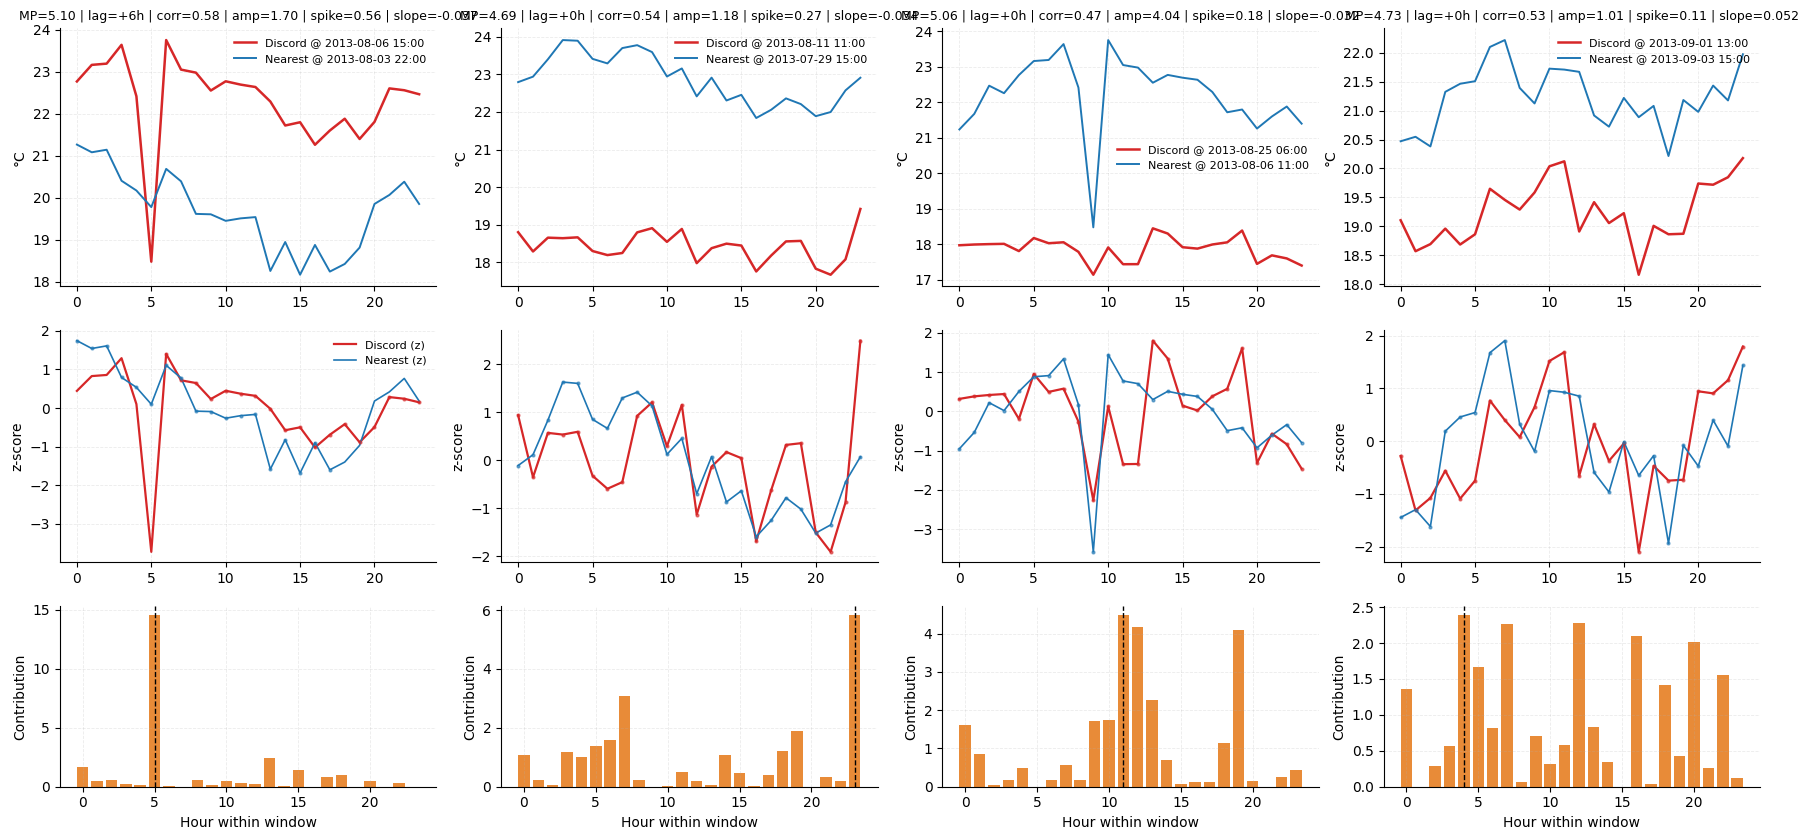

In [26]:
starts4 = events_table["start"].head(4)
_ = plot_mp_reason_grid(
    g, starts4, m=24, max_phase_lag=6,
    save_path="mp_reason_grid_top4.png", dpi=200
)

**Visual explanation of the first 4 Matrix Profile discords (m = 24h)**

**How to read each column**
- **Row 1 (raw °C overlay):** red = discord day, blue = nearest-neighbor day.  
- **Row 2 (z-overlay + phase dots):** same days after per-window z-normalization; dotted points show the best phase alignment (if any).  
- **Row 3 (per-hour contribution):** bars of \((z_d - z_n)^2\); a single tall bar ⇒ a spike hour dominates the distance.

**Column 1 — MP ≈ 5.10, lag = +6 h, corr ≈ 0.58, amp ≈ 1.70, spike ≈ 0.56, slope ≈ −0.07**  
- A **sharp negative spike** around hour ~6 on the discord day that the nearest day does not exhibit.  
- After shifting by **+6 h**, shapes align better ⇒ **phase component** present.  
- Contribution plot: **one dominant bar** (spike_share ~0.56).  
**Interpretation:** **Spike (+ mild phase shift)** drives the distance.

**Column 2 — MP ≈ 4.69, lag = 0 h, corr ≈ 0.54, amp ≈ 1.18, spike ≈ 0.27, slope ≈ −0.04**  
- Mostly flat day with a **late positive jump** (~hour 22).  
- No useful phase shift (lag = 0).  
- Contribution: **dominant end-hour bar** (spike_share ~0.27).  
**Interpretation:** **Single-hour spike** (less dominant than Col.1).

**Column 3 — MP ≈ 5.06, lag = 0 h, corr ≈ 0.47, amp ≈ 4.04, spike ≈ 0.18, slope ≈ 0.00**  
- **Very different day–night range**; the nearest day shows a deep mid-day excursion not present in the discord day.  
- No phase gain; differences are **spread across many hours**.  
**Interpretation:** **Large amplitude change** across the whole day (not a single spike).

**Column 4 — MP ≈ 4.73, lag = 0 h, corr ≈ 0.53, amp ≈ 1.01, spike ≈ 0.11, slope ≈ +0.052**  
- Similar ranges; the discord shows a **subtle upward drift**.  
- Contributions are **distributed** (no single spike).  
**Interpretation:** **Drift / mixed** differences yield a moderate MP.

**Key idea**  
- **Spikes** → few hours dominate the contribution plot.  
- **Phase shift** → better alignment after lag (seen in the dotted z-overlay).  
- **Amplitude change** → different overall range; contributions spread across the day.  
- **Drift** → gradual increase/decrease in z-space with broadly distributed contributions.


-----------------------------------------------------------------------------------------------

#### **Conclusions**

Why IoT anomaly detection must go beyond “shape only”

**Reality of IoT streams.** Sensor data reflects both the **physical process** and the **data pipeline**. An “anomaly” can mean:
- a genuine **physical deviation** (e.g., room overheats),
- a **gradual change** (sensor drift or environmental shift),
- a **data-quality issue** (missing packets, clock skew, duplicate/held values).

If we only look for **shape anomalies** (e.g., via Matrix Profile with per-window z-normalization), we deliberately ignore **absolute level and scale** within each window, so we will **miss** many operationally important events.

**What we would miss with shape-only (z-normalized) methods**
- **Level shifts (absolute hot/cold days):** Uniformly hotter/cooler periods that keep a normal daily pattern.  
  *Impact:* Comfort/energy bugs unnoticed; thresholds breached without “weird shapes.”
- **Excess variance / amplitude:** Unusually large day–night swing or volatility (e.g., HVAC cycling).  
  *Impact:* Higher wear/energy cost; potential instability.
- **Within-window drift:** Monotonic rise/fall across the day (sensor drift or creeping failure).  
  *Impact:* Early warning lost if averaged away by z-normalization.
- **Operational gaps (NaNs) & pipeline faults:** Missing/late data, flatlines, duplicate stamps.  
  *Impact:* Trust/monitoring blind spots; downstream analytics break.

**The complementary signals we use (and why)**
- **B. Shape discords (Matrix Profile, m=24 h):** Catch **behavioral** outliers (phase shifts, spikes, unusual daily shapes).  
- **C. Level anomalies (24 h rolling mean, robust z-score):** Catch **absolute** hot/cold periods.  
- **D. Amplitude/variance anomalies (peak-to-trough, std, robust z):** Catch **excess variability** and cycling issues.  
- **E. Drift anomalies (z-slope within the window):** Catch **gradual changes** that indicate degradation.  
- **A. Operational gaps (NaN runs):** Treat **missing data** as first-class incidents.

**Benefits of a multi-signal approach**
- **Coverage:** Detects what shape-only methods **intentionally ignore** (level/scale/drift/gaps).  
- **Interpretability:** Each alert comes with a **reason** (shape vs. level vs. amplitude vs. drift vs. gap).  
- **Actionability:** Teams can triage **process anomalies** vs **data issues** quickly.  
- **Robustness:** Reduces false negatives when one signal is ambiguous.
 
***To support reliable operations, we combine **Matrix Profile (shape)** with **level/variance/drift/gap** signals and report **non-overlapping events** with clear causes.***
